In [ ]:
import ast

s = '''
match north:
    case Direction.North(A=steps) if steps > 10:
        body1
    case Direction.South as south:
        body2
    case Direction.East | Direction.West:
        body3
    case _:
        body5
'''

print(ast.dump(ast.parse(s), indent=2))

Module(
  body=[
    Match(
      subject=Name(id='north', ctx=Load()),
      cases=[
        match_case(
          pattern=MatchClass(
            cls=Attribute(
              value=Name(id='Direction', ctx=Load()),
              attr='North',
              ctx=Load()),
            kwd_attrs=[
              'A'],
            kwd_patterns=[
              MatchAs(name='steps')]),
          guard=Compare(
            left=Name(id='steps', ctx=Load()),
            ops=[
              Gt()],
            comparators=[
              Constant(value=10)]),
          body=[
            Expr(
              value=Name(id='body1', ctx=Load()))]),
        match_case(
          pattern=MatchAs(
            pattern=MatchValue(
              value=Attribute(
                value=Name(id='Direction', ctx=Load()),
                attr='South',
                ctx=Load())),
            name='south'),
          body=[
            Expr(
              value=Name(id='body2', ctx=Load()))]),
        match_ca

In [9]:
import ast

s = '''
if b == 1:
    a = 6
    return 4
elif b == 0:
    return 9
else:
    return 42    
'''

print(ast.dump(ast.parse(s), indent=2))

Module(
  body=[
    If(
      test=Compare(
        left=Name(id='b', ctx=Load()),
        ops=[
          Eq()],
        comparators=[
          Constant(value=1)]),
      body=[
        Assign(
          targets=[
            Name(id='a', ctx=Store())],
          value=Constant(value=6)),
        Return(
          value=Constant(value=4))],
      orelse=[
        If(
          test=Compare(
            left=Name(id='b', ctx=Load()),
            ops=[
              Eq()],
            comparators=[
              Constant(value=0)]),
          body=[
            Return(
              value=Constant(value=9))],
          orelse=[
            Return(
              value=Constant(value=42))])])])


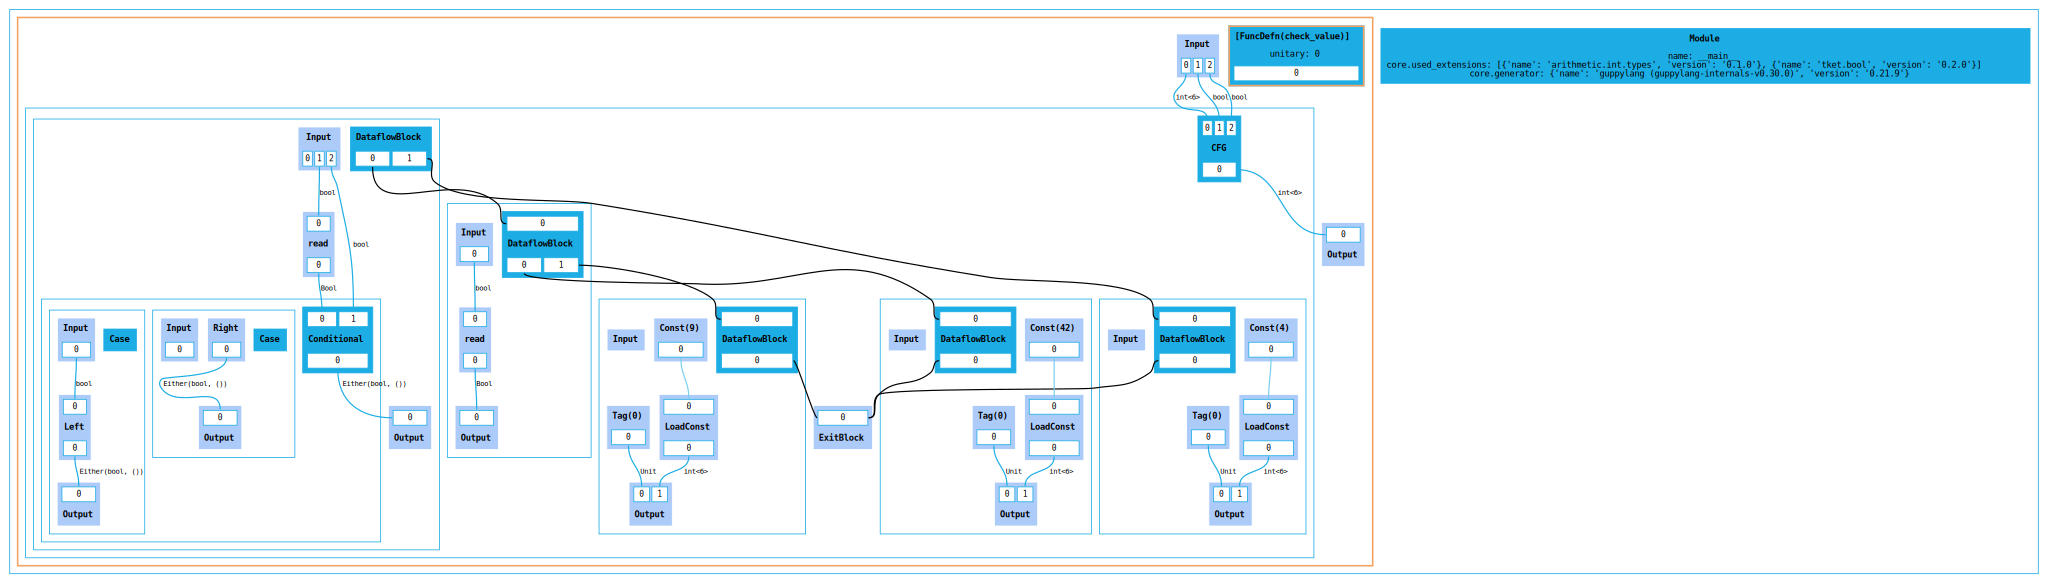

In [4]:

from guppylang import guppy
from guppylang.std.quantum import ch
from typing import Generic  # noqa: F811

@guppy
def check_value(x: int, b: bool, c: bool) -> int:
    if b:
        return 4
    elif c:
        return 9
    else:
        return 42

check_value.compile_function().modules[0].render_dot()

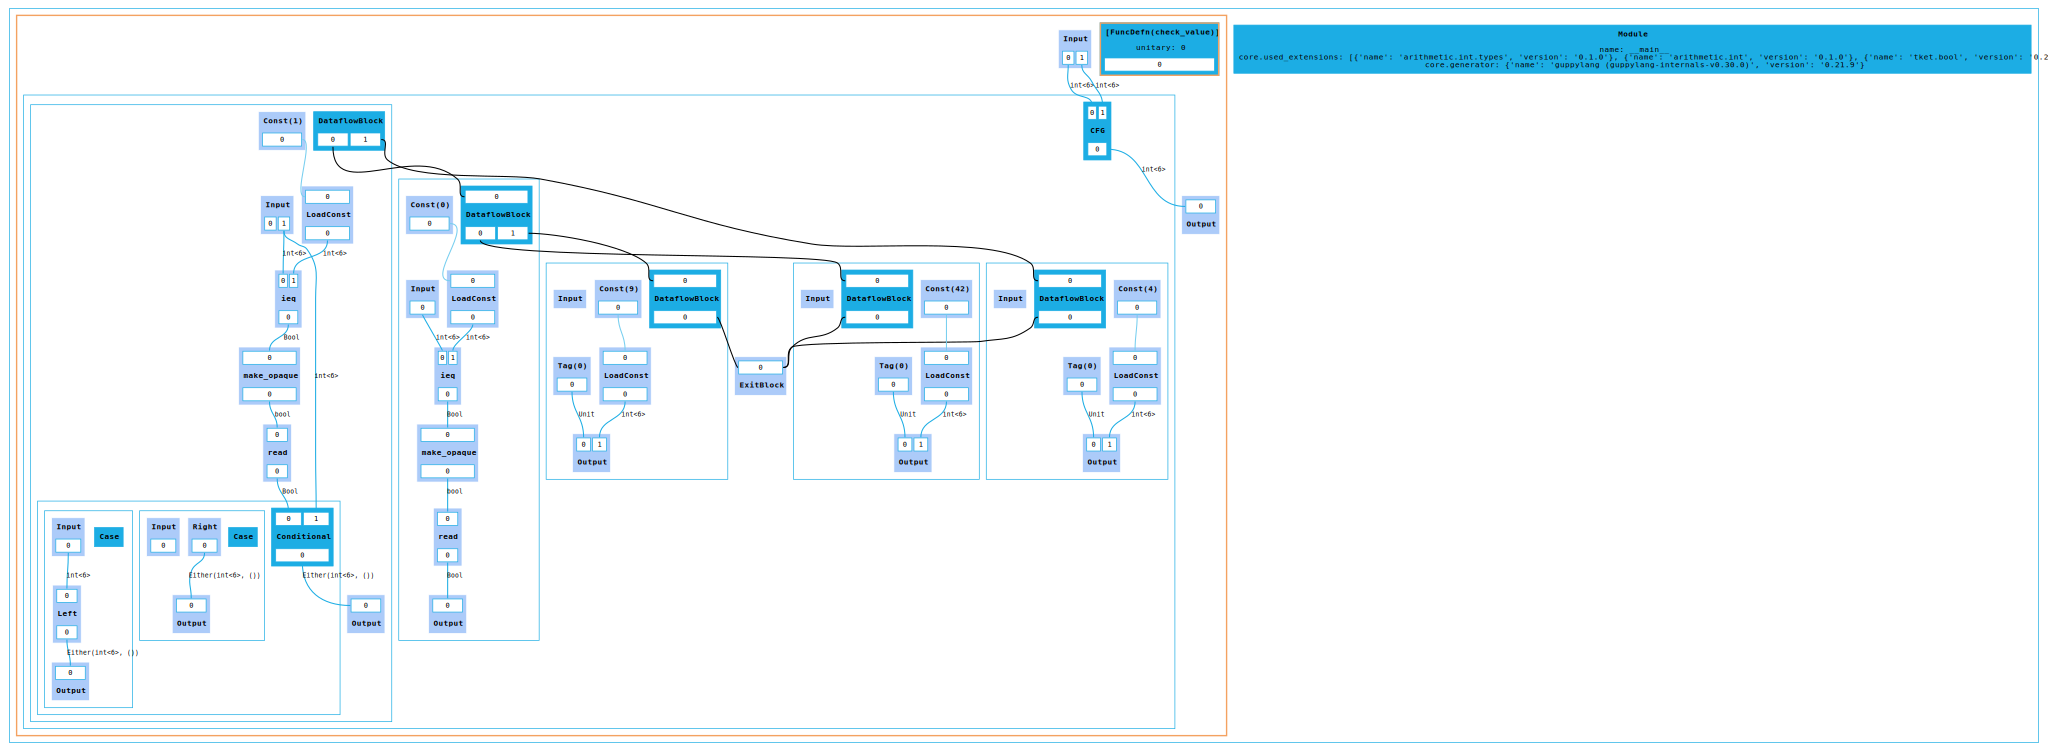

In [6]:

from guppylang import guppy
from guppylang.std.quantum import ch
from typing import Generic  # noqa: F811

@guppy
def check_value(x: int, b: int) -> int:
    if b == 1:
        return 4
    else:
        if b == 0:
            return 9
        else:
            return 42

check_value.compile_function().modules[0].render_dot()

In [3]:
from guppylang import guppy
import guppylang

guppylang.enable_experimental_features()


@guppy.enum
class Direction:
    North = {"A": int}
    South = {"B": int}

@guppy
def main() -> None:
    n = s = 1

main.compile()


Error: Unsupported (at <In[3]>:14:4)
   | 
12 | @guppy
13 | def main() -> None:
14 |     n = s = 1
   |     ^^^^^^^^^ Multi assignments are not supported

Guppy compilation failed due to 1 previous error
